In [6]:
#initial import of relevant packages for graphing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
from rdkit import Chem
from rdkit.Chem import Descriptors
#https://stackoverflow.com/questions/32085531/importing-a-csv-file-into-python-to-make-scatterplots-and-histograms

In [7]:
# Read the CSV
df = pd.read_csv("../../logp_analysis/hcrtr2_project_drugs_3_23_26.csv")

# Optional: inspect the columns
print(df.columns)
display(df.head())

Index(['raw_name', 'id', 'catalog_id', 'predicted_agonist_or_antagonist',
       'drug_shorthand', 'publication_shorthand', 'group', 'pose_ddg',
       'pose_hbonds', 'pose_hbond_energy_sum', 'agonist_screen_rlu',
       'antagonist_screen_rlu', 'tested_in_fish', 'fish_off_target_or_death',
       'smiles_string'],
      dtype='object')


,raw_name,id,catalog_id,predicted_agonist_or_antagonist,drug_shorthand,publication_shorthand,group,pose_ddg,pose_hbonds,pose_hbond_energy_sum,agonist_screen_rlu,antagonist_screen_rlu,tested_in_fish,fish_off_target_or_death,smiles_string
0,Z5052318887,Z5052318887,Z5052318887,agonist,1,8887,gln_agonist,-17.946392,3.0,-1.876331,NaN,NaN,NaN,NaN,CC=1C=CC=CC1CCC(=O)N2C[C@@H]3[C@@](CS3(=O)=O)(...
1,PV-006669822259,Z9331482459,Z9331482459,agonist,2,2259,gln_agonist,-15.084995,3.0,-1.994709,NaN,NaN,NaN,NaN,OC(=O)[C@@H]1C[C@@H](CN1C(=O)COC=2C=CC=3C=CC=C...
2,Z2017261328,Z2017261328,Z2017261328,agonist,3,1328,gln_agonist,-17.928151,3.0,-2.039023,NaN,NaN,NaN,NaN,COC=1C=CC(=CC1S(=O)(=O)NCC=2C=CC=C(C2)N(C)C)S(...
3,Z1679037537,Z1679037537,Z1679037537,agonist,4,7537,gln_agonist,-18.495394,3.0,-2.392914,NaN,NaN,NaN,NaN,COC=1C=CC=CC1CS(=O)(=O)NC(=O)CC(C=2C=CC=CC2)C=...
4,PV-006634533361,Z9331482532,Z9331482532,agonist,6,3361,gln_agonist,-19.126114,3.0,-2.318426,NaN,NaN,NaN,NaN,CC=1C=CC=C(C1)C=2N=C(C3=NNC=4C=CC=CC4C3=O)N(CC...


In [8]:
def compute_descriptors(smiles):
    # Handle missing values
    if pd.isna(smiles):
        return {
            "MW": None,
            "cLogP": None,
            "TPSA": None,
            "HBD": None,
            "HBA": None,
            "RotatableBonds": None,
            "AromaticRings": None,
            "Fsp3": None,
            "logD7.4": None,
            "rdkit_valid": False,
        }

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return {
            "MW": None,
            "cLogP": None,
            "TPSA": None,
            "HBD": None,
            "HBA": None,
            "RotatableBonds": None,
            "AromaticRings": None,
            "Fsp3": None,
            "logD7.4": None,
            "rdkit_valid": False,
        }

    desc = {}
    desc["MW"] = Descriptors.MolWt(mol)
    desc["cLogP"] = Descriptors.MolLogP(mol)
    desc["TPSA"] = Descriptors.TPSA(mol)
    desc["HBD"] = Descriptors.NumHDonors(mol)
    desc["HBA"] = Descriptors.NumHAcceptors(mol)
    desc["RotatableBonds"] = Descriptors.NumRotatableBonds(mol)
    desc["AromaticRings"] = Descriptors.NumAromaticRings(mol)
    desc["Fsp3"] = Descriptors.FractionCSP3(mol)

    # Same simple approximation used in your script
    desc["logD7.4"] = desc["cLogP"]
    desc["rdkit_valid"] = True

    return desc

In [9]:
# Compute descriptors for each row from the smiles_string column
descriptor_df = df["smiles_string"].apply(compute_descriptors).apply(pd.Series)

# Append descriptor columns onto the original dataframe
df = pd.concat([df, descriptor_df], axis=1)

# Check result
display(df.head())

# Optional: save the augmented dataframe
df.to_csv("../../logp_analysis/hcrtr2_project_drugs_3_23_26_with_descriptors.csv", index=False)

,raw_name,id,catalog_id,predicted_agonist_or_antagonist,drug_shorthand,publication_shorthand,group,pose_ddg,pose_hbonds,pose_hbond_energy_sum,...,MW,cLogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,Fsp3,logD7.4,rdkit_valid
0,Z5052318887,Z5052318887,Z5052318887,agonist,1,8887,gln_agonist,-17.946392,3.0,-1.876331,...,369.486,2.50482,54.45,0,3,4,2,0.380952,2.50482,True
1,PV-006669822259,Z9331482459,Z9331482459,agonist,2,2259,gln_agonist,-15.084995,3.0,-1.994709,...,392.411,2.74670,88.96,1,5,6,3,0.227273,2.74670,True
2,Z2017261328,Z2017261328,Z2017261328,agonist,3,1328,gln_agonist,-17.928151,3.0,-2.039023,...,398.506,1.64320,92.78,1,6,7,2,0.294118,1.64320,True
3,Z1679037537,Z1679037537,Z1679037537,agonist,4,7537,gln_agonist,-18.495394,3.0,-2.392914,...,409.507,3.86340,72.47,1,4,8,3,0.173913,3.86340,True
4,PV-006634533361,Z9331482532,Z9331482532,agonist,6,3361,gln_agonist,-19.126114,3.0,-2.318426,...,389.459,3.17552,96.69,2,6,5,4,0.272727,3.17552,True


In [10]:
df

,raw_name,id,catalog_id,predicted_agonist_or_antagonist,drug_shorthand,publication_shorthand,group,pose_ddg,pose_hbonds,pose_hbond_energy_sum,...,MW,cLogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,Fsp3,logD7.4,rdkit_valid
0,Z5052318887,Z5052318887,Z5052318887,agonist,1,8887,gln_agonist,-17.946392,3.0,-1.876331,...,369.486,2.50482,54.45,0,3,4,2,0.380952,2.50482,True
1,PV-006669822259,Z9331482459,Z9331482459,agonist,2,2259,gln_agonist,-15.084995,3.0,-1.994709,...,392.411,2.74670,88.96,1,5,6,3,0.227273,2.74670,True
2,Z2017261328,Z2017261328,Z2017261328,agonist,3,1328,gln_agonist,-17.928151,3.0,-2.039023,...,398.506,1.64320,92.78,1,6,7,2,0.294118,1.64320,True
3,Z1679037537,Z1679037537,Z1679037537,agonist,4,7537,gln_agonist,-18.495394,3.0,-2.392914,...,409.507,3.86340,72.47,1,4,8,3,0.173913,3.86340,True
4,PV-006634533361,Z9331482532,Z9331482532,agonist,6,3361,gln_agonist,-19.126114,3.0,-2.318426,...,389.459,3.17552,96.69,2,6,5,4,0.272727,3.17552,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Lemborexant,Lemborexant,Lemborexant,antagonist,Lemb,Lemb,published_antagonist,NaN,NaN,NaN,...,410.424,3.74204,77.00,1,5,6,3,0.272727,3.74204,True
154,HTL-6641,HTL-6641,HTL-6641,antagonist,HTL,HTL,published_antagonist,NaN,NaN,NaN,...,480.424,3.24660,101.93,0,7,5,3,0.150000,3.24660,True
155,TAK-861,TAK-861,TAK-861,agonist,TAK861,TAK861,published_agonist,NaN,NaN,NaN,...,520.520,3.23830,86.71,2,4,7,2,0.434783,3.23830,True
156,TAK-925,TAK-925,TAK-925,agonist,TAK925,TAK925,published_agonist,NaN,NaN,NaN,...,424.563,2.87800,84.94,1,5,6,1,0.666667,2.87800,True


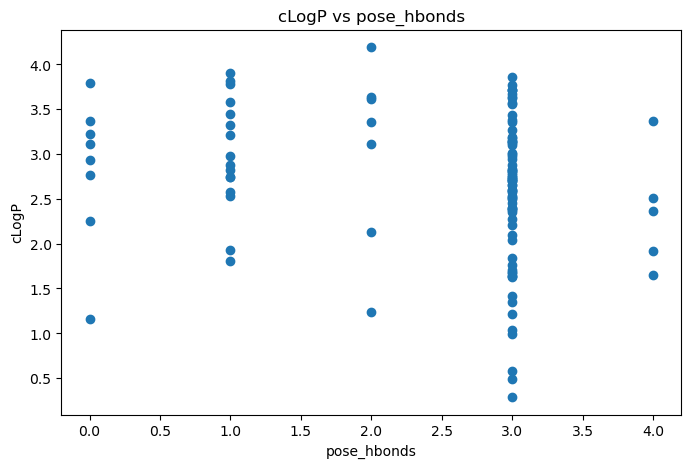

In [12]:
# Keep only rows with a reported pose_hbonds value
df_plot = df[df["pose_hbonds"].notna()].copy()

plt.figure(figsize=(8, 5))
plt.scatter(df_plot["pose_hbonds"], df_plot["cLogP"])
plt.xlabel("pose_hbonds")
plt.ylabel("cLogP")
plt.title("cLogP vs pose_hbonds")
plt.show()

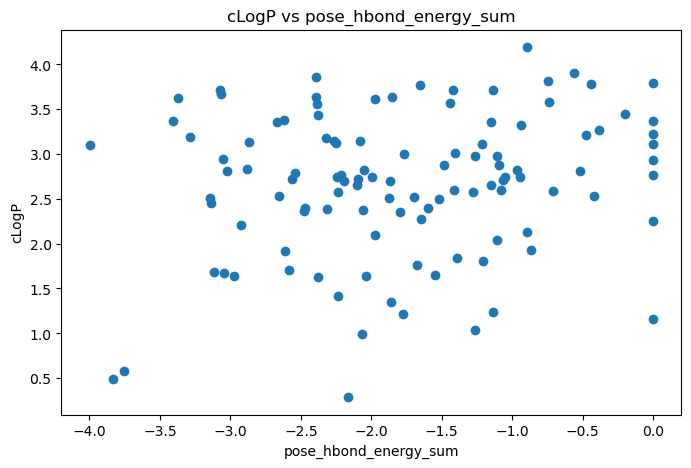

In [14]:
df_plot = df[df["pose_hbonds"].notna()].copy()

plt.figure(figsize=(8, 5))
plt.scatter(df_plot["pose_hbond_energy_sum"], df_plot["cLogP"])
plt.xlabel("pose_hbond_energy_sum")
plt.ylabel("cLogP")
plt.title("cLogP vs pose_hbond_energy_sum")
plt.show()

In [15]:
import pandas as pd

# Keep only rows with valid cLogP and category
df_plot = df[
    df["cLogP"].notna() &
    df["fish_off_target_or_death"].notna()
].copy()

# Optional: enforce consistent labels
df_plot["fish_off_target_or_death"] = df_plot["fish_off_target_or_death"].str.upper()

In [16]:
df_lethal = df_plot[df_plot["fish_off_target_or_death"] == "LETHAL"]
df_ot     = df_plot[df_plot["fish_off_target_or_death"] == "OT"]
df_none   = df_plot[df_plot["fish_off_target_or_death"] == "NONE"]

In [22]:
df_lethal

,raw_name,id,catalog_id,predicted_agonist_or_antagonist,drug_shorthand,publication_shorthand,group,pose_ddg,pose_hbonds,pose_hbond_energy_sum,...,MW,cLogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,Fsp3,logD7.4,rdkit_valid
86,PV-002264977445,Z9588670362,Z9588670362,antagonist,89,7445,low_hbond_antagonist,-18.937169,2.0,-1.975476,...,373.522,3.61302,85.08,2,4,4,2,0.450000,3.61302,True
142,Suvorexant,Suvorexant,Suvorexant,antagonist,Suvo,Suvo,published_antagonist,NaN,NaN,NaN,...,450.930,4.11132,80.29,0,7,3,4,0.304348,4.11132,True
143,Almorexant,Almorexant,Almorexant,antagonist,Almo,Almo,published_antagonist,NaN,NaN,NaN,...,512.572,5.74190,50.80,1,4,8,3,0.344828,5.74190,True
145,JNJ-10397049,JNJ-10397049,JNJ-10397049,antagonist,J7049,J7049,published_antagonist,NaN,NaN,NaN,...,484.188,5.22590,59.59,2,3,3,2,0.315789,5.22590,True
146,IPSU,IPSU,IPSU,antagonist,IPSU,IPSU,published_antagonist,NaN,NaN,NaN,...,405.502,3.37570,74.35,1,5,4,3,0.434783,3.37570,True


In [23]:
df_ot

,raw_name,id,catalog_id,predicted_agonist_or_antagonist,drug_shorthand,publication_shorthand,group,pose_ddg,pose_hbonds,pose_hbond_energy_sum,...,MW,cLogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,Fsp3,logD7.4,rdkit_valid
21,PV-006688879098,Z9331482482,Z9331482482,agonist,24,9098,gln_agonist,-16.893512,3.0,-2.377845,...,393.447,1.62780,89.35,1,6,4,3,0.333333,1.62780,True
29,Z1316825222,Z1316825222,Z1316825222,agonist,32,5222,gln_agonist,-16.580821,3.0,-1.419530,...,412.540,3.71454,76.88,1,6,5,4,0.200000,3.71454,True
33,PV-006439055682,Z8531787886,Z8531787886,antagonist,36,5682,high_hbond_antagonist,-16.064214,3.0,-2.383439,...,360.413,3.56200,75.36,2,4,6,4,0.181818,3.56200,True
35,PV-006204130375,Z9331482795,Z9331482795,antagonist,38,0375,high_hbond_antagonist,-17.305564,3.0,-3.065036,...,366.486,3.67452,59.06,1,3,6,3,0.190476,3.67452,True
48,Z1141296323,Z1141296323,Z1141296323,antagonist,52,6323,high_hbond_antagonist,-20.075722,3.0,-1.439117,...,426.538,3.56870,76.66,2,5,9,3,0.217391,3.56870,True
151,SB-674042,SB-674042,SB-674042,antagonist,SB,SB,published_antagonist,NaN,NaN,NaN,...,448.523,5.15492,72.12,0,6,5,4,0.250000,5.15492,True


In [24]:
df_none

,raw_name,id,catalog_id,predicted_agonist_or_antagonist,drug_shorthand,publication_shorthand,group,pose_ddg,pose_hbonds,pose_hbond_energy_sum,...,MW,cLogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,Fsp3,logD7.4,rdkit_valid
12,PV-006614933798,Z9331482420,Z9331482420,agonist,14,3798,gln_agonist,-17.398477,3.0,-1.654409,...,391.427,3.77292,88.58,1,5,5,4,0.227273,3.77292,True
20,PV-006621251098,Z9331482598,Z9331482598,agonist,23,1098,gln_agonist,-17.973918,3.0,-1.414677,...,389.455,2.59492,91.32,3,4,4,3,0.260870,2.59492,True
24,PV-006710095262,Z9331482494,Z9331482494,agonist,27,5262,gln_agonist,-15.265626,3.0,-2.238594,...,392.459,2.57420,89.53,2,4,4,3,0.318182,2.57420,True
26,PV-006666022285,Z9331482441,Z9331482441,agonist,29,2285,gln_agonist,-19.808601,3.0,-3.287191,...,387.399,3.18692,116.04,2,6,5,4,0.047619,3.18692,True
28,PV-006668031637,Z9331482455,Z9331482455,agonist,31,1637,gln_agonist,-15.783756,3.0,-1.267405,...,392.455,2.97496,82.78,2,4,4,3,0.304348,2.97496,True
31,Z2169713547,Z2169713547,Z2169713547,antagonist,34,3547,high_hbond_antagonist,-18.038823,3.0,-2.468779,...,343.408,2.39332,91.06,3,3,5,3,0.117647,2.39332,True
32,PV-002353454027,Z9331482684,Z9331482684,antagonist,35,4027,high_hbond_antagonist,-19.155136,3.0,-2.389258,...,372.428,3.63260,79.52,2,5,5,4,0.136364,3.63260,True
37,Z1410815299,Z1410815299,Z1410815299,antagonist,40,5299,high_hbond_antagonist,-18.150950,3.0,-2.265566,...,354.450,3.14744,72.63,1,3,8,2,0.333333,3.14744,True
39,Z741186566,Z741186566,Z741186566,antagonist,42,6566,high_hbond_antagonist,-16.618381,3.0,-2.217345,...,379.551,2.76400,75.43,2,4,6,2,0.444444,2.76400,True
44,PV-005396532185,Z9331482773,Z9331482773,antagonist,47,2185,high_hbond_antagonist,-19.486637,3.0,-1.407854,...,394.519,3.01598,66.40,0,4,5,2,0.478261,3.01598,True


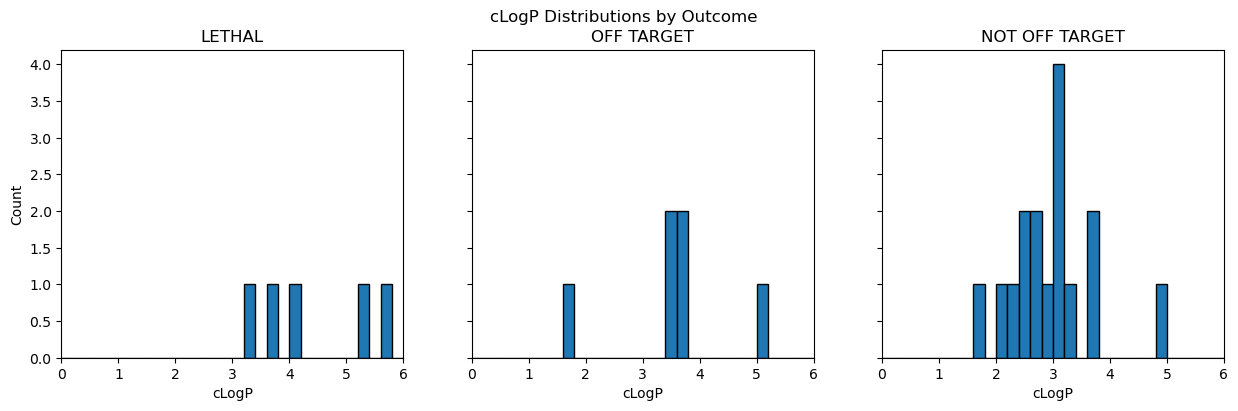

In [30]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Define consistent bins from 0 to 5
bins = np.linspace(0, 6, 31)  # 20 bins between 0–5

axes[0].hist(df_lethal["cLogP"], bins=bins, edgecolor="black")
axes[0].set_title("LETHAL")

axes[1].hist(df_ot["cLogP"], bins=bins, edgecolor="black")
axes[1].set_title("OFF TARGET")

axes[2].hist(df_none["cLogP"], bins=bins, edgecolor="black")
axes[2].set_title("NOT OFF TARGET")

# Apply consistent axis formatting
for ax in axes:
    ax.set_xlabel("cLogP")
    ax.set_xlim(0, 6)  # force same x-range

axes[0].set_ylabel("Count")

plt.suptitle("cLogP Distributions by Outcome")
plt.show()

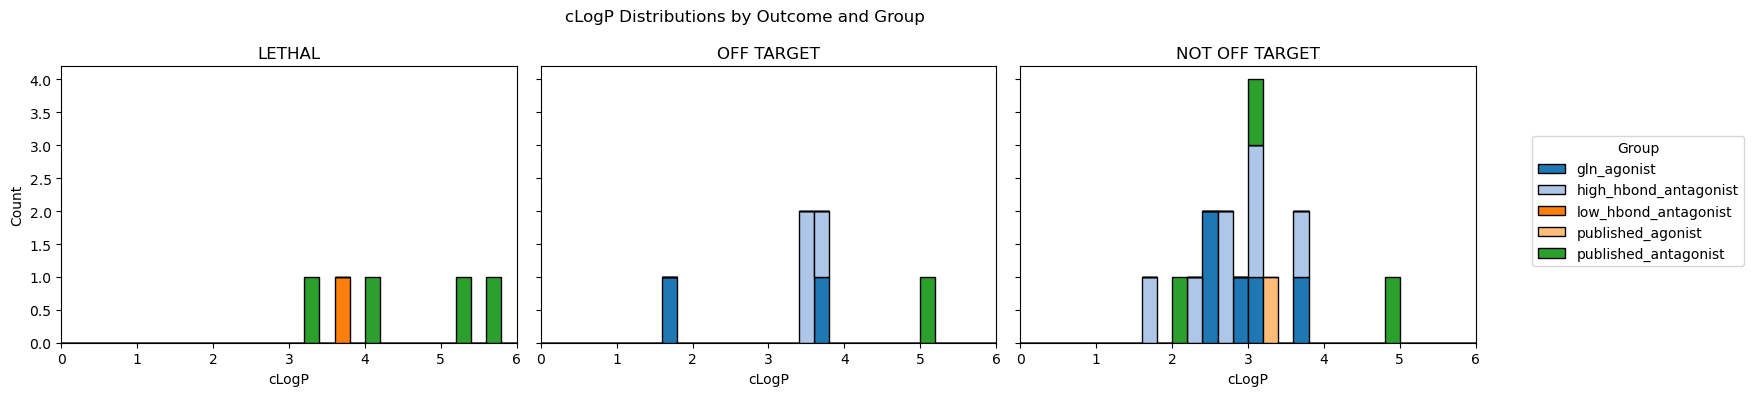

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Make a clean plotting dataframe
df_plot = df.copy()
df_plot = df_plot[df_plot["cLogP"].notna() & df_plot["fish_off_target_or_death"].notna() & df_plot["group"].notna()].copy()

# Standardize labels if needed
df_plot["fish_off_target_or_death"] = df_plot["fish_off_target_or_death"].astype(str).str.upper().str.strip()
df_plot["group"] = df_plot["group"].astype(str).str.strip()

# Outcome subsets
df_lethal = df_plot[df_plot["fish_off_target_or_death"] == "LETHAL"].copy()
df_ot     = df_plot[df_plot["fish_off_target_or_death"] == "OT"].copy()
df_none   = df_plot[df_plot["fish_off_target_or_death"] == "NONE"].copy()

# Global group order across the entire dataset
group_order = sorted(df_plot["group"].unique())

# Fixed bins and x range
bins = np.linspace(0, 6, 31)

# Build a fixed color map for all groups
cmap = plt.get_cmap("tab20")
group_colors = {g: cmap(i % 20) for i, g in enumerate(group_order)}

def grouped_clogp_all_groups(df_subset, group_order):
    """
    Return one cLogP array per group in the exact same order every time.
    Missing groups get an empty array, which preserves color alignment.
    """
    data = []
    for g in group_order:
        vals = df_subset.loc[df_subset["group"] == g, "cLogP"].dropna().values
        data.append(vals)
    return data

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Always use the same group order and same colors
lethal_data = grouped_clogp_all_groups(df_lethal, group_order)
ot_data     = grouped_clogp_all_groups(df_ot, group_order)
none_data   = grouped_clogp_all_groups(df_none, group_order)

color_list = [group_colors[g] for g in group_order]

axes[0].hist(lethal_data, bins=bins, stacked=True, edgecolor="black", color=color_list)
axes[0].set_title("LETHAL")

axes[1].hist(ot_data, bins=bins, stacked=True, edgecolor="black", color=color_list)
axes[1].set_title("OFF TARGET")

axes[2].hist(none_data, bins=bins, stacked=True, edgecolor="black", color=color_list)
axes[2].set_title("NOT OFF TARGET")

for ax in axes:
    ax.set_xlabel("cLogP")
    ax.set_xlim(0, 6)

axes[0].set_ylabel("Count")

# Build legend manually from the fixed color map
legend_handles = [Patch(facecolor=group_colors[g], edgecolor="black", label=g) for g in group_order]
#fig.legend(handles=legend_handles, title="Group", loc="upper right")
fig.legend(
    handles=legend_handles,
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)  # pushes it outside to the right
)

plt.suptitle("cLogP Distributions by Outcome and Group")
plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import kruskal

stat, p = kruskal(
    df_lethal["cLogP"],
    df_ot["cLogP"],
    df_none["cLogP"]
)

print("Kruskal-Wallis H:", stat)
print("p-value:", p)

Kruskal-Wallis H: 8.50681216931217
p-value: 0.01421573136952025


In [34]:
from scipy.stats import mannwhitneyu

def compare(a, b, name1, name2):
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    print(f"{name1} vs {name2}: U={stat:.2f}, p={p:.4f}")

compare(df_lethal["cLogP"], df_ot["cLogP"], "LETHAL", "OT")
compare(df_lethal["cLogP"], df_none["cLogP"], "LETHAL", "NONE")
compare(df_ot["cLogP"], df_none["cLogP"], "OT", "NONE")

LETHAL vs OT: U=21.00, p=0.3290
LETHAL vs NONE: U=73.00, p=0.0041
OT vs NONE: U=70.00, p=0.1148
